In [1]:
#!pip install transformers datasets torch scikit-learn pandas

In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    AutoConfig
)
import os
from huggingface_hub import HfApi


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from datasets import Dataset

# Load CSV
df = pd.read_csv("/content/du_lieu_mapped.csv")

# Chỉ giữ cột cần thiết: text + label
df = df[['query', 'label']]

# Chuyển sang HuggingFace Dataset
dataset = Dataset.from_pandas(df)


print(df.head())


                                             query  label
0       Tạo cho tôi 10 câu hỏi về lịch sử Việt Nam      0
1          Sinh câu hỏi trắc nghiệm môn toán lớp 9      0
2                  Cho tôi vài câu hỏi về khoa học      0
3         Làm câu hỏi kiểm tra kiến thức tiếng Anh      0
4  Tạo câu hỏi phỏng vấn cho vị trí lập trình viên      0


In [ ]:
import pandas as pd

df['label'].value_counts()


,count
label,
0,406
1,403
2,379


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# df là DataFrame ban đầu
train_df, val_df = train_test_split(
    df, test_size=0.2, shuffle=True, stratify=df['label'], random_state=42
)

# Chuyển sang HF Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)


In [ ]:
print(val_df.head())

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['query'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)


In [ ]:
columns = ['input_ids', 'attention_mask', 'label']

train_dataset.set_format(type='torch', columns=columns)
val_dataset.set_format(type='torch', columns=columns)

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = 3  # vì bạn có 3 nhãn: 0/1/2
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./phobert_query_ft",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()


In [ ]:
model.save_pretrained("./phobert_query_ft_model")
tokenizer.save_pretrained("./phobert_query_ft_model")


('./phobert_query_ft_model/tokenizer_config.json',
 './phobert_query_ft_model/special_tokens_map.json',
 './phobert_query_ft_model/vocab.txt',
 './phobert_query_ft_model/bpe.codes',
 './phobert_query_ft_model/added_tokens.json')

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


MODEL_PATH = "/content/phobert_query_ft_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)


model.eval()


queries = [
    "Phân tích đáp án này về CAP theorem có logic chặt chẽ không",
]

inputs = tokenizer(queries, padding=True, truncation=True, return_tensors="pt")


with torch.no_grad():  # tắt gradient để tiết kiệm RAM
    outputs = model(**inputs)
    logits = outputs.logits


predicted_class_ids = torch.argmax(logits, dim=1)

id2label = {0: "label_0", 1: "label_1", 2: "label_2"}  # thay theo dataset của bạn
predicted_labels = [id2label[i.item()] for i in predicted_class_ids]


for query, label in zip(queries, predicted_labels):
    print(f"Query: {query}\nPredicted label: {label}\n")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Query: Phân tích đáp án này về CAP theorem có logic chặt chẽ không
Predicted label: label_1



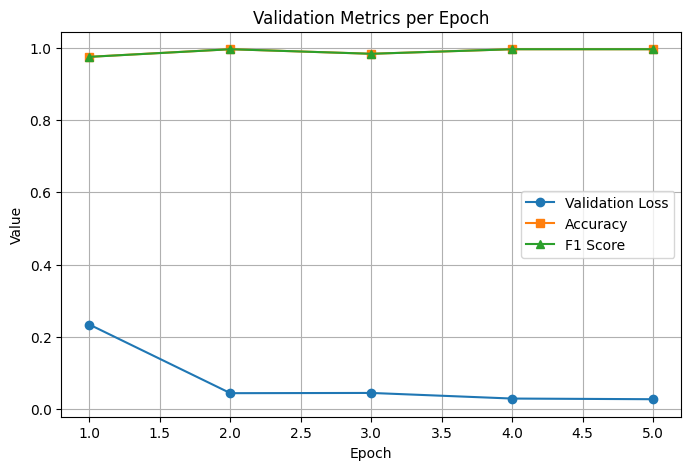

In [ ]:
import matplotlib.pyplot as plt

# Dữ liệu từ bảng
epochs = [1, 2, 3, 4, 5]
val_loss = [0.234001, 0.044250, 0.044906, 0.029389, 0.027536]
accuracy = [0.974790, 0.995798, 0.983193, 0.995798, 0.995798]
f1 = [0.974693, 0.995798, 0.983182, 0.995798, 0.995798]

# Tạo biểu đồ line chart
plt.figure(figsize=(8,5))
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.plot(epochs, accuracy, marker='s', label='Accuracy')
plt.plot(epochs, f1, marker='^', label='F1 Score')

# Thêm thông tin hiển thị
plt.title('Validation Metrics per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
api = HfApi(token=os.getenv("HF_API_TOKEN"))
api.upload_folder(
    folder_path="/content/phobert_query_ft_model",
    repo_id="khacdiep2208/phobert-finetuned-query-classification",
    repo_type="model",
)

In [ ]:
user = api.whoami()
print(user)


In [ ]:
from huggingface_hub import HfApi, Repository


repo_id = "khacdiep2208/phobert-finetuned-query-classification"
repo = Repository(local_dir="/content/phobert_query_ft", clone_from=repo_id)

# Copy các file checkpoint vào folder local_dir nếu chưa có
# rồi commit + push
repo.push_to_hub(commit_message="Upload checkpoint")


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load tokenizer và model trực tiếp từ Hub
tokenizer = AutoTokenizer.from_pretrained("khacdiep2208/phobert-finetuned-query-classification")
model = AutoModelForSequenceClassification.from_pretrained("khacdiep2208/phobert-finetuned-query-classification")

# Tạo pipeline để inference
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Test
texts = ["""xin chào bạn là ai
"""]
results = classifier(texts)
print(results)


Device set to use cuda:0


[{'label': 'LABEL_2', 'score': 0.7587085366249084}]
